In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jharilova/data-set-prediction-house/4) house Prediction Data Set.csv


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/jharilova/data-set-prediction-house/4) house Prediction Data Set.csv


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt




In [4]:
df = pd.read_csv('/kaggle/input/datasets/jharilova/data-set-prediction-house/4) house Prediction Data Set.csv', 
                 sep='\s+', header=0)

# Verify
       #
print(df.head())


   0.00632  18.00  2.310  0  0.5380  6.5750  65.20  4.0900  1  296.0  15.30  \
0  0.02731    0.0   7.07  0   0.469   6.421   78.9  4.9671  2  242.0   17.8   
1  0.02729    0.0   7.07  0   0.469   7.185   61.1  4.9671  2  242.0   17.8   
2  0.03237    0.0   2.18  0   0.458   6.998   45.8  6.0622  3  222.0   18.7   
3  0.06905    0.0   2.18  0   0.458   7.147   54.2  6.0622  3  222.0   18.7   
4  0.02985    0.0   2.18  0   0.458   6.430   58.7  6.0622  3  222.0   18.7   

   396.90  4.98  24.00  
0  396.90  9.14   21.6  
1  392.83  4.03   34.7  
2  394.63  2.94   33.4  
3  396.90  5.33   36.2  
4  394.12  5.21   28.7  


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_16/1196464629.py:2: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+', header=0)


In [5]:
print(df.shape)   

(505, 14)


In [6]:
print(df.columns)


Index(['0.00632', '18.00', '2.310', '0', '0.5380', '6.5750', '65.20', '4.0900',
       '1', '296.0', '15.30', '396.90', '4.98', '24.00'],
      dtype='object')


In [7]:
# If columns are not automatically named, set them
df.columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']

In [8]:
df.sample

<bound method NDFrame.sample of         CRIM   ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.02731  0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
1    0.02729  0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
2    0.03237  0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
3    0.06905  0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   
4    0.02985  0.0   2.18     0  0.458  6.430  58.7  6.0622    3  222.0   
..       ...  ...    ...   ...    ...    ...   ...     ...  ...    ...   
500  0.06263  0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273.0   
501  0.04527  0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273.0   
502  0.06076  0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273.0   
503  0.10959  0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273.0   
504  0.04741  0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       17.8  396.90   9.14  21.6  
1      

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     505 non-null    float64
 1   ZN       505 non-null    float64
 2   INDUS    505 non-null    float64
 3   CHAS     505 non-null    int64  
 4   NOX      505 non-null    float64
 5   RM       505 non-null    float64
 6   AGE      505 non-null    float64
 7   DIS      505 non-null    float64
 8   RAD      505 non-null    int64  
 9   TAX      505 non-null    float64
 10  PTRATIO  505 non-null    float64
 11  B        505 non-null    float64
 12  LSTAT    505 non-null    float64
 13  MEDV     505 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.4 KB


In [10]:
# Statistical summary for numerical features
display(df.describe())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,3.620667,11.350495,11.154257,0.069307,0.554728,6.284059,68.581584,3.794459,9.566337,408.459406,18.461782,356.594376,12.668257,22.529901
std,8.608572,23.343704,6.855868,0.254227,0.115990,0.703195,28.176371,2.107757,8.707553,168.629992,2.162520,91.367787,7.139950,9.205991
min,0.009060,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082210,0.000000,5.190000,0.000000,0.449000,5.885000,45.000000,2.100000,4.000000,279.000000,17.400000,375.330000,7.010000,17.000000
50%,0.259150,0.000000,9.690000,0.000000,0.538000,6.208000,77.700000,3.199200,5.000000,330.000000,19.100000,391.430000,11.380000,21.200000
75%,3.678220,12.500000,18.100000,0.000000,0.624000,6.625000,94.100000,5.211900,24.000000,666.000000,20.200000,396.210000,16.960000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [11]:
# check a missing values
missing = df.isna().sum()
print(missing)

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [12]:
# check for duplicate rows
print(df.duplicated().sum())

0


# split features (x) and target (y)

In [13]:
X = df.drop('MEDV', axis=1) # all feature columns
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


# Train and evaluate linear regression

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print(f"MSE :: {mse_lr : .2f}")
print(f"R2 : {r2_lr : 4f}")

Linear Regression
MSE ::  19.38
R2 :  0.652220


# Model Decision tree

In [15]:
dt = DecisionTreeRegressor(random_state =42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Model Random forest

In [16]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

### Collect results

In [17]:
results = pd.DataFrame({
    "Model" : ["Linear Regression", "Decision Tree", 'Random Forest'],
    "MSE" : [mse_lr, mean_squared_error(y_test, y_pred_dt), mean_squared_error(y_test, y_pred_rf)],
    "R2" : [r2_lr, r2_score(y_test, y_pred_dt), r2_score(y_test, y_pred_rf)]
})

print(results)

               Model        MSE        R2
0  Linear Regression  19.379041  0.652220
1      Decision Tree  20.856733  0.625701
2      Random Forest   7.579063  0.863985


# Visualize Predictions vs actual 

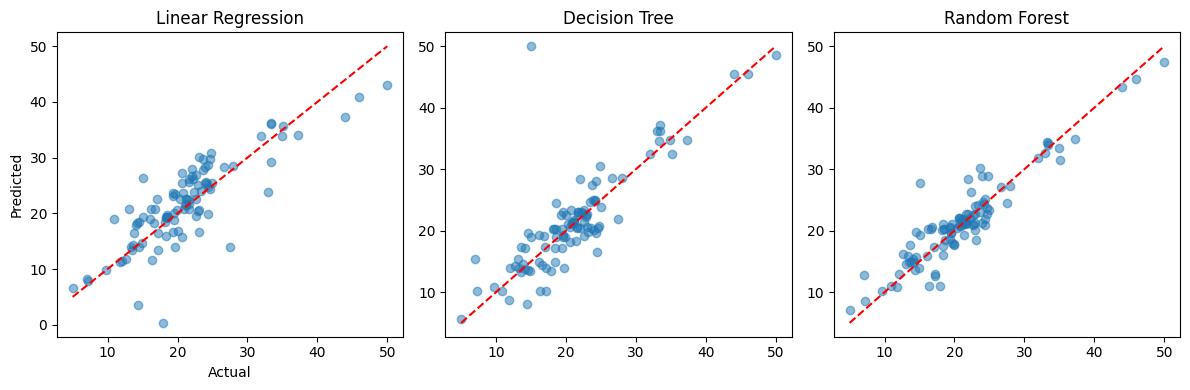

In [18]:
plt.figure(figsize=(12,4))
plt.subplot(131)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('Linear Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(132)
plt.scatter(y_test, y_pred_dt, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('Decision Tree')

plt.subplot(133)
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('Random Forest')
plt.tight_layout()
plt.show()